# 🩸 Non-Invasive Glucose Estimation via PPG Signal
**Satria Data Competition — Statistics Essay Category**

---
## Dataset Structure
```
PPG_Dataset/
├── Figures/        → fig_XX_YYYY.jpg   (plot of each PPG recording)
├── Labels/         → label_XX_YYYY.mat (glucose ground truth per recording)
└── RawData/        → signal_XX_YYYY.mat (raw ADC signal, 10 sec @ 2190 Hz)
```
- `XX`   = Subject ID (e.g. 01, 02, 03 ...)
- `YYYY` = Recording number per subject (e.g. 0001, 0002 ...)

**Label = ONE glucose value per recording** (glucometer reading at time of capture, NOT per peak)

## Cell 1 — Imports & Config

In [2]:
!pip install numpy matplotlib scipy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 1.5 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 782.4 kB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 973.0 kB/s  0:00:21m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.0 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.3 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [matplotlib]0 [matplotlib]


In [5]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG: point this to your dataset root ──
DATASET_ROOT = './'   # change if needed

RAW_DIR  = os.path.join(DATASET_ROOT, 'RawData')
LAB_DIR  = os.path.join(DATASET_ROOT, 'Labels')
FIG_DIR  = os.path.join(DATASET_ROOT, 'Figures')

FS       = 2190   # sampling frequency (Hz) — 21900 samples / 10 sec
DURATION = 10     # seconds per recording

print('Dataset root :', DATASET_ROOT)
print('Exists       :', os.path.exists(DATASET_ROOT))

Dataset root : ./
Exists       : True


## Cell 2 — Scan All Files & Count Recordings

In [6]:
# Find all signal files
signal_files = sorted(glob.glob(os.path.join(RAW_DIR, 'signal_*.mat')))
label_files  = sorted(glob.glob(os.path.join(LAB_DIR, 'label_*.mat')))

print(f'Total signal files : {len(signal_files)}')
print(f'Total label files  : {len(label_files)}')
print()

# Parse subject IDs from filenames
def parse_id(filepath):
    """Extract (subject_id, recording_id) from filename like signal_01_0003.mat"""
    name = os.path.basename(filepath)         # signal_01_0003.mat
    parts = name.replace('.mat','').split('_') # ['signal','01','0003']
    return int(parts[1]), int(parts[2])        # (1, 3)

subjects = {}
for f in signal_files:
    subj, rec = parse_id(f)
    subjects.setdefault(subj, []).append(rec)

print('Subjects found:')
for subj, recs in subjects.items():
    print(f'  Subject {subj:02d} → {len(recs)} recordings: {recs}')

print(f'\nTotal subjects     : {len(subjects)}')
print(f'Total recordings   : {sum(len(v) for v in subjects.values())}')

Total signal files : 67
Total label files  : 67

Subjects found:
  Subject 01 → 7 recordings: [1, 2, 3, 4, 5, 6, 7]
  Subject 02 → 3 recordings: [1, 2, 3]
  Subject 03 → 2 recordings: [1, 2]
  Subject 04 → 5 recordings: [1, 2, 3, 4, 5]
  Subject 05 → 6 recordings: [1, 2, 3, 4, 5, 6]
  Subject 06 → 2 recordings: [1, 2]
  Subject 07 → 4 recordings: [1, 2, 3, 4]
  Subject 08 → 2 recordings: [1, 2]
  Subject 09 → 2 recordings: [1, 2]
  Subject 10 → 2 recordings: [1, 2]
  Subject 11 → 4 recordings: [1, 2, 3, 4]
  Subject 12 → 1 recordings: [1]
  Subject 13 → 2 recordings: [1, 2]
  Subject 14 → 2 recordings: [1, 2]
  Subject 15 → 3 recordings: [1, 2, 3]
  Subject 16 → 3 recordings: [1, 2, 3]
  Subject 17 → 2 recordings: [1, 2]
  Subject 18 → 3 recordings: [1, 2, 3]
  Subject 19 → 2 recordings: [1, 2]
  Subject 20 → 3 recordings: [1, 2, 3]
  Subject 21 → 2 recordings: [1, 2]
  Subject 22 → 3 recordings: [1, 2, 3]
  Subject 23 → 2 recordings: [1, 2]

Total subjects     : 23
Total recordings   

## Cell 3 — Inspect a Single Signal File

In [7]:
# Load one signal file and print everything inside
sample_signal_path = signal_files[0]
print('File:', os.path.basename(sample_signal_path))
print('─' * 40)

mat = sio.loadmat(sample_signal_path)

print('Keys in .mat file:')
for key, val in mat.items():
    if key.startswith('_'):
        continue   # skip metadata keys like __header__, __version__
    arr = np.array(val)
    print(f'  [{key}]')
    print(f'    shape  : {arr.shape}')
    print(f'    dtype  : {arr.dtype}')
    print(f'    min    : {arr.min()}')
    print(f'    max    : {arr.max()}')
    print(f'    mean   : {arr.mean():.2f}')
    print(f'    sample : {arr.flatten()[:8]} ...')

signal = mat['signal'].flatten().astype(float)
time   = np.arange(len(signal)) / FS

print(f'\nDerived info:')
print(f'  Sampling rate : {FS} Hz')
print(f'  Duration      : {len(signal)/FS:.1f} seconds')
print(f'  Total samples : {len(signal)}')

File: signal_01_0001.mat
────────────────────────────────────────
Keys in .mat file:
  [signal]
    shape  : (21900, 1)
    dtype  : uint16
    min    : 495
    max    : 526
    mean   : 511.87
    sample : [503 503 503 502 502 502 502 502] ...

Derived info:
  Sampling rate : 2190 Hz
  Duration      : 10.0 seconds
  Total samples : 21900


## Cell 4 — Inspect a Single Label File

In [17]:
# ⚠️  Label files are stored as MATLAB Table (MCOS format)
# scipy.io cannot decode MATLAB Tables directly.
# Two options:
#   A) Use MATLAB/Octave to convert labels to a readable format
#   B) Read the label value manually from the raw binary
import pandas as pd

sample_label_path = label_files[0]
print('File:', os.path.basename(sample_label_path))
print('─' * 40)

lab = sio.loadmat(sample_label_path)

print('Keys in .mat file:')
for key, val in lab.items():
    print(f'  {key} → {type(val).__name__}')
    
print()
print('⚠️  Label is stored as a MATLAB Table (MCOS object).')
print('   scipy.io cannot decode this format.')
print()
print('👉 Fix options:')
print('   1. In MATLAB: run  writetable(T_temp, "label_01_0001.csv")  for each file')
print('   2. Use GNU Octave (free): pkg load io; data = load("label_01_0001.mat")')
print('   3. If labels are a single value, rename variable to plain double in MATLAB')
print('      then resave:  glucose = T_temp.glucose;  save("label_01_0001.mat", "glucose")')

File: label_01_0001.mat
────────────────────────────────────────
Keys in .mat file:
  __header__ → bytes
  __version__ → str
  __globals__ → list
  None → MatlabOpaque
  __function_workspace__ → ndarray

⚠️  Label is stored as a MATLAB Table (MCOS object).
   scipy.io cannot decode this format.

👉 Fix options:
   1. In MATLAB: run  writetable(T_temp, "label_01_0001.csv")  for each file
   2. Use GNU Octave (free): pkg load io; data = load("label_01_0001.mat")
   3. If labels are a single value, rename variable to plain double in MATLAB
      then resave:  glucose = T_temp.glucose;  save("label_01_0001.mat", "glucose")


## Cell 5 — MATLAB conversion script (run this in MATLAB)

If you have MATLAB access, run the script below once to convert all labels to `.csv`.
Then Cell 6 will read them cleanly in Python.

```matlab
% === run_once_convert_labels.m ===
label_dir = './PPG_Dataset/Labels/';
files = dir(fullfile(label_dir, 'label_*.mat'));

for i = 1:length(files)
    fpath = fullfile(label_dir, files(i).name);
    load(fpath);                        % loads variable T_temp (a table)
    csv_name = strrep(files(i).name, '.mat', '.csv');
    writetable(T_temp, fullfile(label_dir, csv_name));
    fprintf('Saved: %s\n', csv_name);
end
```

## Cell 6 — Load Labels (after CSV conversion)

In [ ]:
import pandas as pd

# After running the MATLAB script above, labels are in CSV
label_csvs = sorted(glob.glob(os.path.join(LAB_DIR, 'label_*.csv')))

if len(label_csvs) == 0:
    print('⚠️  No CSV labels found yet.')
    print('   Please run the MATLAB conversion script in Cell 5 first.')
else:
    print(f'Found {len(label_csvs)} label CSV files')
    
    # Load one to inspect columns
    df_sample = pd.read_csv(label_csvs[0])
    print('\nSample label CSV:')
    print(df_sample.head())
    print('Columns:', df_sample.columns.tolist())

## Cell 7 — Plot a Single PPG Signal

In [ ]:
mat    = sio.loadmat(signal_files[0])
signal = mat['signal'].flatten().astype(float)
time   = np.arange(len(signal)) / FS

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ── Top: Raw signal ──
axes[0].plot(time, signal, color='steelblue', linewidth=0.8)
axes[0].set_title(f'Raw PPG Signal — {os.path.basename(signal_files[0])}', fontsize=13)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('ADC Value (uint16)')
axes[0].grid(True, alpha=0.3)

# ── Bottom: First 2 seconds zoom ──
mask = time <= 2.0
axes[1].plot(time[mask], signal[mask], color='tomato', linewidth=1.2)
axes[1].set_title('Zoomed: First 2 Seconds (individual heartbeats visible)', fontsize=13)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('ADC Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quick stats
print('Signal stats:')
print(f'  Samples   : {len(signal)}')
print(f'  Min       : {signal.min()}')
print(f'  Max       : {signal.max()}')
print(f'  Range     : {signal.max() - signal.min()}')
print(f'  Mean      : {signal.mean():.2f}')
print(f'  Std       : {signal.std():.2f}')

## Cell 8 — Compare Signals Across Subjects

In [ ]:
# Plot first recording from each subject side by side
first_per_subject = {}
for f in signal_files:
    subj, rec = parse_id(f)
    if subj not in first_per_subject:
        first_per_subject[subj] = f

n_subj = len(first_per_subject)
fig, axes = plt.subplots(n_subj, 1, figsize=(14, 3 * n_subj), sharex=True)
if n_subj == 1:
    axes = [axes]

colors = plt.cm.tab10.colors

for i, (subj, fpath) in enumerate(sorted(first_per_subject.items())):
    mat    = sio.loadmat(fpath)
    sig    = mat['signal'].flatten().astype(float)
    t      = np.arange(len(sig)) / FS
    axes[i].plot(t, sig, color=colors[i % 10], linewidth=0.7)
    axes[i].set_ylabel(f'Subject {subj:02d}\nADC', fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (sec)')
fig.suptitle('First Recording per Subject — Raw PPG Signal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

ECG Sampling Frequency: 1000 Hz
ECG Signal Shape: (1, 10000)
PPG Sampling Frequency: 30 Hz


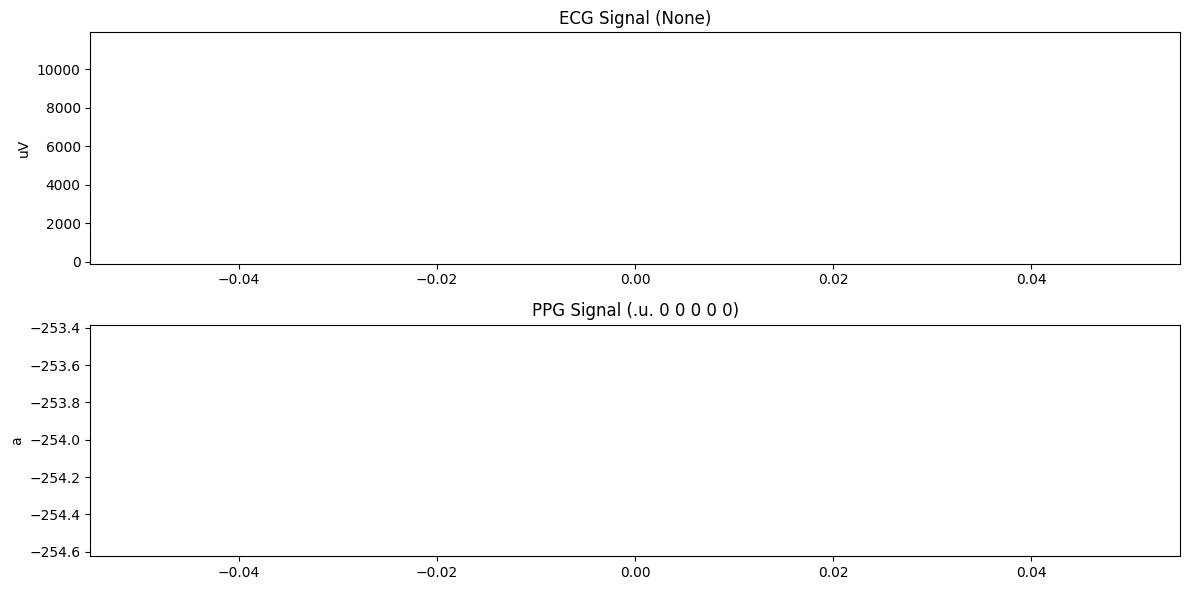

In [20]:
import wfdb
import matplotlib.pyplot as plt

# 1. Read the ECG record
# Note: Use the base name without .dat or .hea
ecg_record = wfdb.rdrecord('./brno/100002/100002_ECG')
ecg_signal = ecg_record.p_signal

# 2. Read the PPG record
ppg_record = wfdb.rdrecord('./brno/100002/100002_PPG')
ppg_signal = ppg_record.p_signal

# 3. Print metadata
print(f"ECG Sampling Frequency: {ecg_record.fs} Hz")
print(f"ECG Signal Shape: {ecg_signal.shape}")
print(f"PPG Sampling Frequency: {ppg_record.fs} Hz")

# 4. Plot a segment (first 1000 samples)
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(ecg_signal[:1000])
plt.title(f"ECG Signal ({ecg_record.sig_name[0]})")
plt.ylabel(ecg_record.units[0])

plt.subplot(2, 1, 2)
plt.plot(ppg_signal[:1000], color='red')
plt.title(f"PPG Signal ({ppg_record.sig_name[0]})")
plt.ylabel(ppg_record.units[0])

plt.tight_layout()
plt.show()